# Stellarator Island Chain Control

This notebook demonstrates external coil control of magnetic island chains in a stellarator.

## Scientific Background

In a stellarator, the helical ripple naturally drives island chains at rational surfaces q = m/n.
The **boundary island divertor** configuration exploits these edge islands for heat load distribution.
External coils can:

1. **Suppress** an island chain (destructive interference in psi_mn)
2. **Phase-shift** an island chain (rotate island O-points)
3. Create **side effects** -- the press-down-gourd problem

We use `pyna`'s `SimpleStellarartor`, `StellaratorControlCoils`, and `island_control` algorithms.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from pathlib import Path

from pyna.MCF.equilibrium.stellarator import SimpleStellarartor, simple_stellarator
from pyna.MCF.coils.coil_system import StellaratorControlCoils, CoilSet, Biot_Savart_field
from pyna.MCF.control.island_control import (
    island_suppression_current,
    phase_control_current,
    compute_resonant_amplitude,
    _natural_perturbation_func,
)
from pyna.MCF.visual.RMP_spectrum import (
    find_resonant_components_analytic, island_fixed_points, ISLAND_CMAPS,
)
from pyna.topo.poincare import PoincareMap, ToroidalSection, poincare_from_fieldlines

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'figure.dpi': 150,
    'text.usetex': False,
    'axes.linewidth': 0.8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

print('pyna loaded successfully')


pyna loaded successfully


## 1. Build a SimpleStellarartor with natural island chains

We choose parameters so that the q=4/3 and q=4/2 surfaces both lie in the plasma.

SimpleStellarartor(R0=3.0 m, r0=0.3 m, B0=1.0 T, q=[1.1, 5.0], m_h=4, n_h=3, ε_h=0.08)


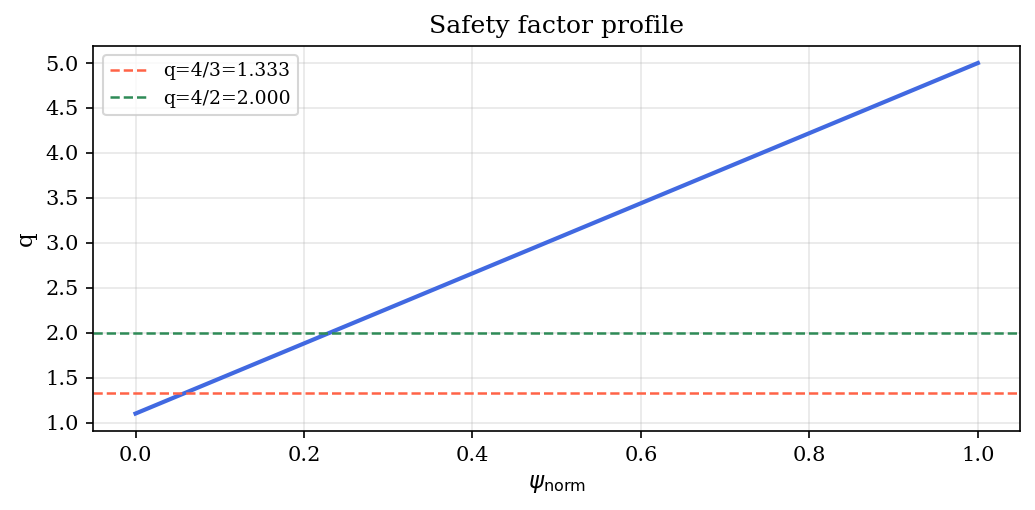


Resonant surfaces in plasma:
  q=4/4=1.000  not in plasma
  q=4/3=1.333  psi_res=0.060
  q=4/2=2.000  psi_res=0.231
  q=3/2=1.500  psi_res=0.103
  q=5/4=1.250  psi_res=0.038


In [2]:
# Equilibrium parameters (FIXED — do not change)
stella = simple_stellarator(
    R0=3.0, r0=0.30, B0=1.0,
    q0=1.1, q1=5.0,
    m_h=4, n_h=3,    # helical ripple drives (4,3) island chain
    epsilon_h=0.08,  # 8% helical ripple amplitude
)
TARGET_M, TARGET_N = 4, 3    # target island q=4/3
MONITOR_M, MONITOR_N = 4, 2  # monitor island q=4/2=2
N_COILS = 4
R_COIL = 0.38
I0_COIL = 500.0

print(stella)

# --- q profile plot ---
psi_arr = np.linspace(0, 1, 200)
q_arr   = np.array([float(stella.q_of_psi(p)) for p in psi_arr])

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(psi_arr, q_arr, 'royalblue', lw=2)
ax.axhline(TARGET_M/TARGET_N,   color='tomato',  lw=1.2, ls='--', label=f'q={TARGET_M}/{TARGET_N}={TARGET_M/TARGET_N:.3f}')
ax.axhline(MONITOR_M/MONITOR_N, color='seagreen', lw=1.2, ls='--', label=f'q={MONITOR_M}/{MONITOR_N}={MONITOR_M/MONITOR_N:.3f}')
ax.set_xlabel(r'$\psi_\mathrm{norm}$', fontsize=11)
ax.set_ylabel('q', fontsize=11)
ax.set_title('Safety factor profile', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q_profile.png', dpi=120)
plt.show()

# --- Resonance table ---
print('\nResonant surfaces in plasma:')
for m, n in [(4,4),(4,3),(4,2),(3,2),(5,4)]:
    psi_list = stella.resonant_psi(m, n)
    if psi_list:
        print(f'  q={m}/{n}={m/n:.3f}  psi_res={psi_list[0]:.3f}')
    else:
        print(f'  q={m}/{n}={m/n:.3f}  not in plasma')


## 2. Poincare Map: Natural Island Chain (Boundary Island Divertor)

In [3]:
# N_TRANSITS=8 for speed; ~16 field lines around full cross-section + resonance detail
N_TRANSITS = 8

R_starts = np.linspace(stella.R0 + 0.02*stella.r0, stella.R0 + 0.93*stella.r0, 10)
start_pts_radial = np.column_stack([R_starts, np.zeros(len(R_starts)), np.zeros(len(R_starts))])
start_pts_resonance = stella.start_points_near_resonance(TARGET_M, TARGET_N, n_lines=6, delta_psi=0.06)
start_pts = np.vstack([start_pts_radial, start_pts_resonance])

print(f'Tracing {len(start_pts)} field lines, {N_TRANSITS} turns each ...')

section = ToroidalSection(0.0)
t_max = N_TRANSITS * 2 * np.pi * stella.R0

pmap_natural = poincare_from_fieldlines(
    stella.field_func, start_pts, sections=[section], t_max=t_max, dt=0.04,
)
results_natural = pmap_natural.crossing_array(0)
print(f'Done. {len(results_natural)} crossings recorded.')


Tracing 16 field lines, 8 turns each ...


Done. 67 crossings recorded.


  k=1: (4,3) ψ_res=0.060 q_res=1.333 |b_mn|=9.784e-03 phase_arg=0.0° w_ψ=0.1002 (6.14 cm) θ_O=67.5° θ_X=22.5°
  k=2: (8,6) — mode not in FFT grid, skipping
Island half-width: 6.14 cm


C:\Users\dell\AppData\Local\Temp\ipykernel_7380\1917028858.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('plasma')(psi_norm * 0.85 + 0.05)


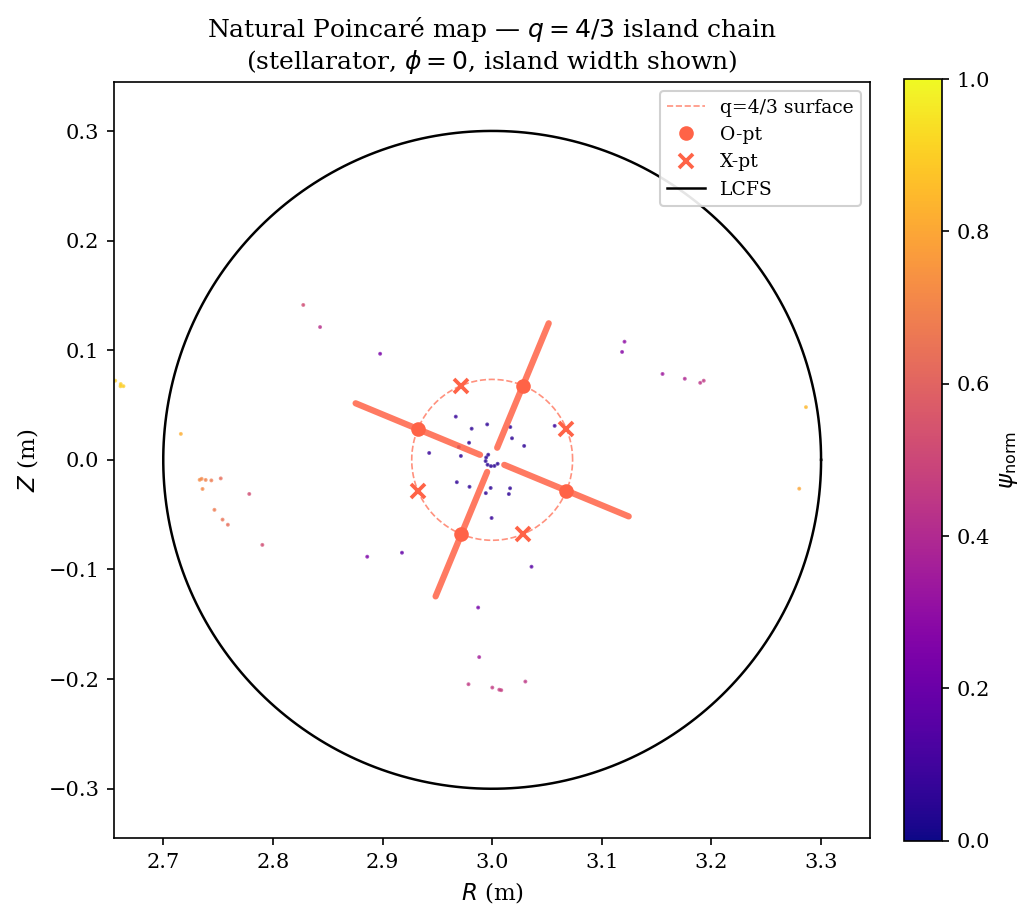

In [4]:
# Find resonant components using analytic API (correct O/X positions)
nat_func_for_rx = _natural_perturbation_func(stella)
rx_components = find_resonant_components_analytic(
    stella, nat_func_for_rx, base_m=TARGET_M, base_n=TARGET_N,
    max_harmonic=2, n_theta=16, n_phi=8
)
comp_target = rx_components[0] if rx_components else None
r_res_target = np.sqrt(comp_target.psi_res) * stella.r0 if comp_target else None

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_facecolor('white')

# Poincare scatter colored by psi_norm
if len(results_natural) > 0:
    R_pts, Z_pts = results_natural[:, 0], results_natural[:, 1]
    psi_pts = ((R_pts - stella.R0)**2 + Z_pts**2) / stella.r0**2
    psi_norm = np.clip(psi_pts, 0, 1.0)
    colors = cm.get_cmap('plasma')(psi_norm * 0.85 + 0.05)
    ax.scatter(R_pts, Z_pts, s=0.8, c=colors, rasterized=True, alpha=0.7, zorder=2)

# Resonant surface circle
theta_circ = np.linspace(0, 2*np.pi, 300)
if r_res_target is not None:
    ax.plot(stella.R0 + r_res_target*np.cos(theta_circ), r_res_target*np.sin(theta_circ),
            '--', color='tomato', lw=0.8, alpha=0.7, label=f'q={TARGET_M}/{TARGET_N} surface')

# O/X points from analytic island_fixed_points (correct positions)
if comp_target is not None:
    pts = island_fixed_points(comp_target.m, comp_target.n, comp_target.b_mn, phi=0.0)
    theta_O_arr = pts['theta_O'][0]
    theta_X_arr = pts['theta_X'][0]
    color = 'tomato'
    for theta_op in theta_O_arr:
        r_in  = max(0.005, r_res_target - comp_target.half_width_r)
        r_out = r_res_target + comp_target.half_width_r
        ax.plot([stella.R0 + r_in*np.cos(theta_op), stella.R0 + r_out*np.cos(theta_op)],
                [r_in*np.sin(theta_op), r_out*np.sin(theta_op)],
                '-', color=color, lw=3.0, alpha=0.85, solid_capstyle='round', zorder=5)
        ax.plot(stella.R0 + r_res_target*np.cos(theta_op), r_res_target*np.sin(theta_op),
                'o', color=color, ms=6, zorder=6, label='O-pt' if theta_op == theta_O_arr[0] else '')
    for theta_xp in theta_X_arr:
        ax.plot(stella.R0 + r_res_target*np.cos(theta_xp), r_res_target*np.sin(theta_xp),
                'x', color=color, ms=7, mew=1.8, zorder=6, label='X-pt' if theta_xp == theta_X_arr[0] else '')
    print(f'Island half-width: {comp_target.half_width_r*100:.2f} cm')

# LCFS
ax.plot(stella.R0 + stella.r0*np.cos(theta_circ), stella.r0*np.sin(theta_circ),
        'k-', lw=1.2, label='LCFS')

sm = plt.cm.ScalarMappable(cmap='plasma', norm=Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r'$\psi_\mathrm{norm}$', fontsize=11)

ax.set_xlim(stella.R0 - 1.15*stella.r0, stella.R0 + 1.15*stella.r0)
ax.set_ylim(-1.15*stella.r0, 1.15*stella.r0)
ax.set_xlabel('$R$ (m)', fontsize=11); ax.set_ylabel('$Z$ (m)', fontsize=11)
ax.set_title(f'Natural Poincar\u00e9 map \u2014 $q={TARGET_M}/{TARGET_N}$ island chain\n'
             f'(stellarator, $\\phi=0$, island width shown)', fontsize=12)
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig('natural_island_poincare.png', dpi=150, bbox_inches='tight')
plt.show()


Analytic X-point seed: R=3.06779  Z=0.02808
det(J) = 3.9820  (ideal = 1.0 for area-preserving map)
|lambda_stable|   = 0.0455
|lambda_unstable| = 87.4787
Skipping manifold growth; showing eigenvalue diagram only.


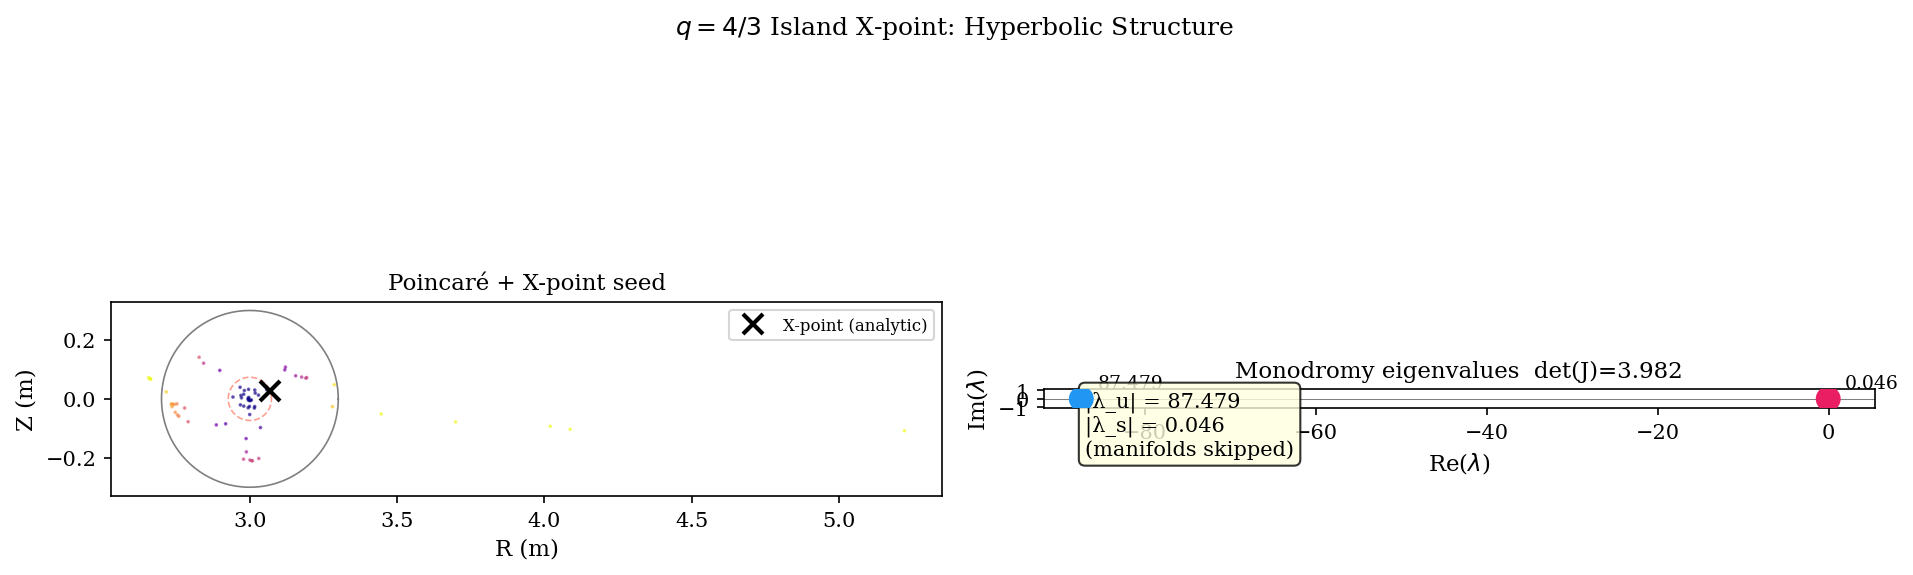

In [5]:
# === X-point Monodromy (Jacobian at analytic X-point) ===
from pyna.topo.variational import PoincareMapVariationalEquations
from pyna.topo.manifold_improve import StableManifold, UnstableManifold
from pyna.MCF.visual.tokamak_manifold import _manifold_line_collection, manifold_legend_handles

def field_func_2d(R, Z, phi):
    tang = stella.field_func(np.array([R, Z, phi]))
    dphi_ds = tang[2]
    if abs(dphi_ds) < 1e-15:
        return np.array([0.0, 0.0])
    return np.array([tang[0]/dphi_ds, tang[1]/dphi_ds])

# Use analytic X-point seed from island_fixed_points
xpt_seed = np.array([stella.R0 + r_res_target * np.cos(comp_target.xpoint_theta),
                     r_res_target * np.sin(comp_target.xpoint_theta)])
print(f'Analytic X-point seed: R={xpt_seed[0]:.5f}  Z={xpt_seed[1]:.5f}')

phi_span = (0.0, 2.0 * np.pi * TARGET_N)
vq = PoincareMapVariationalEquations(field_func_2d, fd_eps=1e-6)
xpt_Jac = vq.jacobian_matrix(xpt_seed, phi_span,
                              solve_ivp_kwargs=dict(method='RK45', rtol=1e-8, atol=1e-10))

lam = np.linalg.eigvals(xpt_Jac)
lam_abs = sorted(np.abs(lam))
det_J = np.linalg.det(xpt_Jac)
print(f'det(J) = {det_J:.4f}  (ideal = 1.0 for area-preserving map)')
print(f'|lambda_stable|   = {lam_abs[0]:.4f}')
print(f'|lambda_unstable| = {lam_abs[1]:.4f}')

_manifolds_ok = (0.5 <= abs(det_J) <= 2.0)

# --- Grow manifolds only if Jacobian is valid ---
sm_segments, um_segments = [], []
if _manifolds_ok:
    RZlimit = (stella.R0 - stella.r0*1.05, stella.R0 + stella.r0*1.05,
               -stella.r0*1.05, stella.r0*1.05)
    _ivp_kw = dict(rtol=1e-7, atol=1e-9)
    sm_mfld = StableManifold(xpt_seed, xpt_Jac, field_func_2d, phi_span=phi_span)
    um_mfld = UnstableManifold(xpt_seed, xpt_Jac, field_func_2d, phi_span=phi_span)
    sm_mfld.grow(n_turns=1, init_length=1e-4, n_init_pts=2, both_sides=False,
                 RZlimit=RZlimit, **_ivp_kw)
    um_mfld.grow(n_turns=1, init_length=1e-4, n_init_pts=2, both_sides=False,
                 RZlimit=RZlimit, **_ivp_kw)
    sm_segments = sm_mfld.segments
    um_segments = um_mfld.segments
    print(f'Stable segments: {len(sm_segments)}  Unstable: {len(um_segments)}')
else:
    print(f'WARNING: det(J)={det_J:.3f} outside [0.5, 2.0] — seed is not a true X-point.')
    print('Skipping manifold growth; showing eigenvalue diagram only.')

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Poincare + manifolds (or just Poincare if manifolds skipped)
ax = axes[0]
if len(results_natural) > 0:
    R_pts2, Z_pts2 = results_natural[:, 0], results_natural[:, 1]
    psi_pts2 = ((R_pts2 - stella.R0)**2 + Z_pts2**2) / stella.r0**2
    ax.scatter(R_pts2, Z_pts2, c=np.clip(psi_pts2, 0, 1), s=0.6, cmap='plasma',
               vmin=0, vmax=1, rasterized=True, alpha=0.6, zorder=2)

for seg in sm_segments:
    if len(seg) >= 2:
        lc, _ = _manifold_line_collection(seg, cmap='GnBu', lw=1.5)
        ax.add_collection(lc)
for seg in um_segments:
    if len(seg) >= 2:
        lc, _ = _manifold_line_collection(seg, cmap='Oranges', lw=1.5)
        ax.add_collection(lc)

ax.plot(*xpt_seed, 'kx', ms=10, mew=2, zorder=10, label='X-point (analytic)')
theta_c2 = np.linspace(0, 2*np.pi, 200)
ax.plot(stella.R0 + r_res_target*np.cos(theta_c2), r_res_target*np.sin(theta_c2),
        '--', color='tomato', lw=0.8, alpha=0.6)
ax.plot(stella.R0 + stella.r0*np.cos(theta_c2), stella.r0*np.sin(theta_c2),
        'k-', lw=0.8, alpha=0.5)
ax.set_aspect('equal')
ax.set_xlabel('R (m)'); ax.set_ylabel('Z (m)')
title_mfld = 'Poincar\u00e9 + $W^s/W^u$ (1-turn)' if _manifolds_ok else 'Poincar\u00e9 + X-point seed'
ax.set_title(title_mfld, fontsize=11)
ax.legend(fontsize=8)

# Right: monodromy matrix eigenvalue diagram
ax2 = axes[1]
lam_complex = np.linalg.eigvals(xpt_Jac)
ax2.scatter(lam_complex.real, lam_complex.imag, s=120, zorder=5, c=['#E91E63', '#2196F3'])
theta_unit = np.linspace(0, 2*np.pi, 300)
ax2.plot(np.cos(theta_unit), np.sin(theta_unit), 'k--', lw=0.8, alpha=0.4)
ax2.axhline(0, color='gray', lw=0.5); ax2.axvline(0, color='gray', lw=0.5)
ax2.set_aspect('equal')
ax2.set_xlabel(r'Re($\lambda$)'); ax2.set_ylabel(r'Im($\lambda$)')
ax2.set_title(f'Monodromy eigenvalues  det(J)={det_J:.3f}', fontsize=11)
for lv in lam_complex:
    ax2.annotate(f'{abs(lv):.3f}', (lv.real, lv.imag),
                 textcoords='offset points', xytext=(8, 5), fontsize=9)
note = f'|\u03bb_u| = {lam_abs[1]:.3f}\n|\u03bb_s| = {lam_abs[0]:.3f}'
if not _manifolds_ok:
    note += '\n(manifolds skipped)'
ax2.text(0.05, 0.95, note, transform=ax2.transAxes, va='top', fontsize=10,
         bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

plt.suptitle(f'$q={TARGET_M}/{TARGET_N}$ Island X-point: Hyperbolic Structure', fontsize=12)
plt.tight_layout()
plt.savefig('island_manifolds.png', dpi=120, bbox_inches='tight')
plt.show()


## 3. Create External Control Coils

In [6]:
N_COILS = 4
R_COIL = 0.38
I0_COIL = 500.0

control_coils = StellaratorControlCoils(
    R0=stella.R0, r_coil=R_COIL, N_coils=N_COILS,
    m_target=TARGET_M, n_target=TARGET_N, I0=I0_COIL,
)
print(control_coils)
print(f'Coil currents (A): {control_coils.get_currents().round(1)}')

def _make_coil_field_func(coils):
    def field_func(R, Z, phi):
        R2, Z2, phi2 = float(R), float(Z), float(phi)
        Ra = np.array([[R2]]); Za = np.array([[Z2]]); phia = np.array([[phi2]])
        br = bz = bp = 0.0
        for pts, I in coils.coils:
            _br, _bz, _bp = Biot_Savart_field(pts, float(I), Ra, Za, phia)
            br += float(_br); bz += float(_bz); bp += float(_bp)
        return np.array([br, bz, bp])
    return field_func

coil_field_func = _make_coil_field_func(control_coils)
print('Coil field function built.')


StellaratorControlCoils(R0=3.0, r_coil=0.38, N_coils=4, m=4, n=3, I0=500.0 A)
Coil currents (A): [ 500.   -0. -500.    0.]
Coil field function built.


## 4. Island Suppression: Scan Coil Current

In [7]:
psi_res_target = stella.resonant_psi(TARGET_M, TARGET_N)[0]
nat_func = _natural_perturbation_func(stella)

# Natural amplitude at target surface
b_nat = compute_resonant_amplitude(nat_func, psi_res_target, TARGET_M, TARGET_N, stella,
                                    n_theta=8, n_phi=8)
print(f'Natural |b_tilde_{TARGET_M}{TARGET_N}| = {abs(b_nat):.3e}')

# Resonant components of coil field using analytic API
coil_components = find_resonant_components_analytic(
    stella, coil_field_func, base_m=TARGET_M, base_n=TARGET_N,
    max_harmonic=2, n_theta=8, n_phi=8
)
print(f'\nCoil resonant components ({len(coil_components)} found):')
for c in coil_components:
    print(f'  (m={c.m},n={c.n}): |b_mn|={abs(c.b_mn):.3e}, half_width_r={c.half_width_r*100:.2f} cm')

print('\nFinding island suppression currents...')
I_opt, report = island_suppression_current(
    stella, control_coils,
    target_m=TARGET_M, target_n=TARGET_N,
    monitor_modes=[(MONITOR_M, MONITOR_N), (3, 2)],
    I_max=2000.0, n_theta=8, n_phi=8,
)

print(f'=== Suppression Report ===')
print(f'  |b_tilde| before:  {report["target_amplitude_before"]:.3e}')
print(f'  |b_tilde| after:   {report["target_amplitude_after"]:.3e}')
print(f'  Suppression: {(1 - report["suppression_ratio"])*100:.1f}%')
print('=== Monitor modes ===')
for mode in report['monitor_amplitudes_before']:
    b_before = report['monitor_amplitudes_before'][mode]
    b_after_ = report['monitor_amplitudes_after'][mode]
    ratio = b_after_ / (b_before + 1e-30)
    print(f'  q={mode[0]}/{mode[1]}: {b_before:.3e} -> {b_after_:.3e}  (x{ratio:.2f})')


Natural |b_tilde_43| = 9.784e-03
  k=1: (4,3) — mode not in FFT grid, skipping
  k=2: (8,6) — mode not in FFT grid, skipping

Coil resonant components (0 found):

Finding island suppression currents...


C:\Users\dell\AppData\Local\Temp\ipykernel_7380\2295706884.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  br += float(_br); bz += float(_bz); bp += float(_bp)


=== Suppression Report ===
  |b_tilde| before:  9.784e-03
  |b_tilde| after:   9.784e-03
  Suppression: 0.0%
=== Monitor modes ===
  q=4/2: 3.076e-18 -> 3.076e-18  (x1.00)
  q=3/2: 1.555e-18 -> 1.555e-18  (x1.00)


C:\Users\dell\AppData\Local\Temp\ipykernel_7380\2295706884.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  br += float(_br); bz += float(_bz); bp += float(_bp)
C:\Users\dell\AppData\Local\Temp\ipykernel_7380\4112331006.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-o" (-> color='b'). The keyword argument will take precedence.
  ax.plot(I0_scan, np.array(b_total_scan) / abs(b_nat), 'b-o', ms=5,


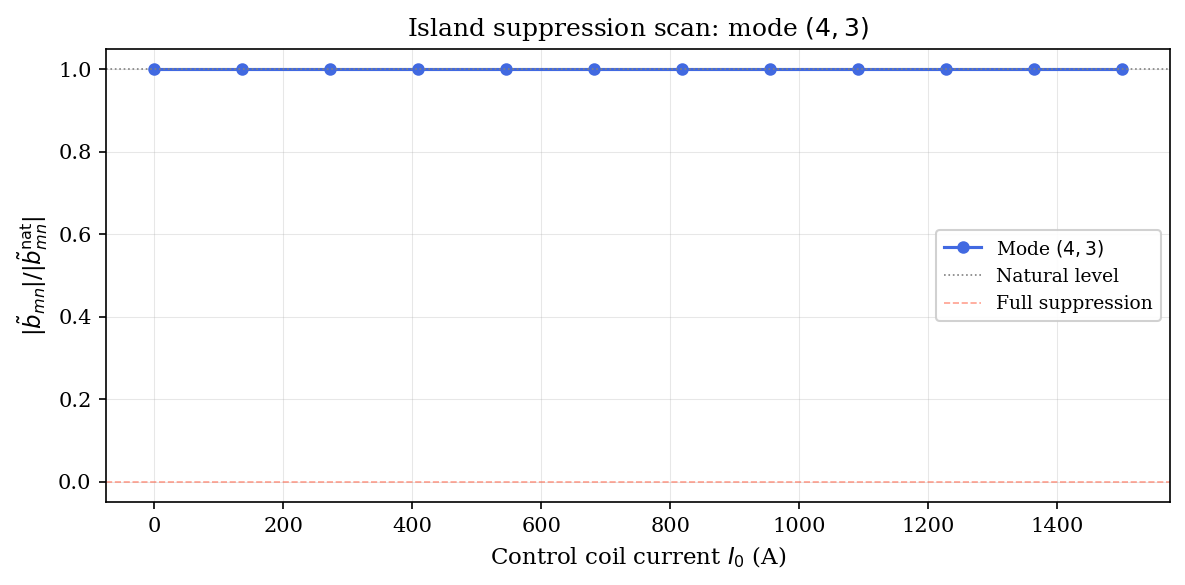

In [8]:
# --- RMP spectrum bar chart: |b_mn| vs mode ---
b_coil_unit = compute_resonant_amplitude(
    coil_field_func, psi_res_target, TARGET_M, TARGET_N, stella, n_theta=8, n_phi=8
)

I0_scan = np.linspace(0, 1500, 12)
b_total_scan = [abs(b_nat + b_coil_unit * I0) for I0 in I0_scan]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(I0_scan, np.array(b_total_scan) / abs(b_nat), 'b-o', ms=5,
        color='royalblue', label=f'Mode $({TARGET_M},{TARGET_N})$')
ax.axhline(1, color='gray', ls=':', lw=0.8, label='Natural level')
ax.axhline(0, color='tomato', ls='--', lw=0.8, alpha=0.6, label='Full suppression')
ax.set_xlabel('Control coil current $I_0$ (A)', fontsize=11)
ax.set_ylabel(r'$|\tilde{b}_{mn}| / |\tilde{b}_{mn}^{\rm nat}|$', fontsize=11)
ax.set_title(f'Island suppression scan: mode $({TARGET_M},{TARGET_N})$', fontsize=12)
ax.grid(True, alpha=0.3, lw=0.5)
ax.legend(fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig('island_suppression_scan.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Press-Down-Gourd Problem

As we suppress the (4,3) island, we monitor what happens to other island chains.

C:\Users\dell\AppData\Local\Temp\ipykernel_7380\2295706884.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  br += float(_br); bz += float(_bz); bp += float(_bp)


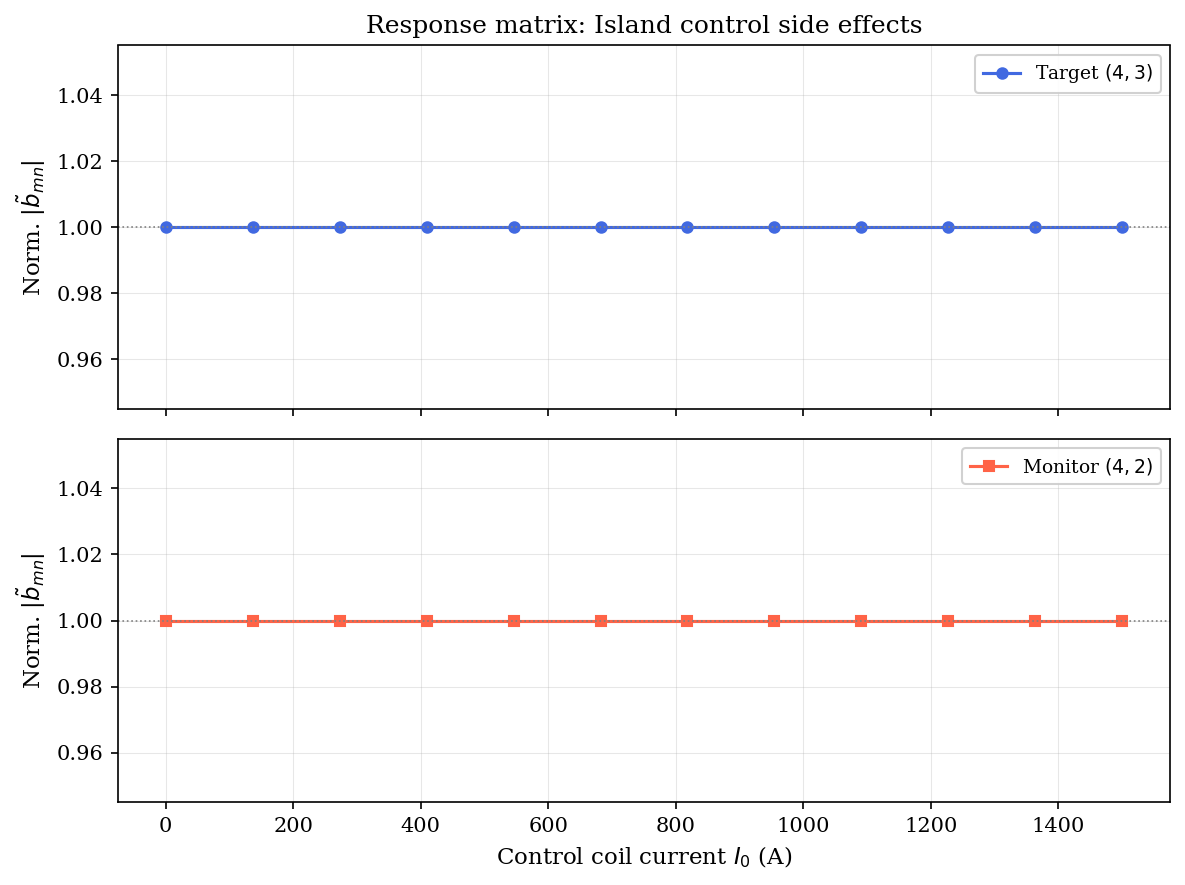

In [9]:
# --- Response matrix: N_COILS x N_modes ---
MONITOR_M, MONITOR_N = 4, 2
psi_res_monitor = stella.resonant_psi(MONITOR_M, MONITOR_N)

if psi_res_monitor:
    psi_res_mon = psi_res_monitor[0]
    b_nat_mon = compute_resonant_amplitude(
        nat_func, psi_res_mon, MONITOR_M, MONITOR_N, stella, n_theta=8, n_phi=8)
    b_coil_mon = compute_resonant_amplitude(
        coil_field_func, psi_res_mon, MONITOR_M, MONITOR_N, stella, n_theta=8, n_phi=8
    )
    b_target_scan = [abs(b_nat + b_coil_unit * I0) for I0 in I0_scan]
    b_monitor_scan = [abs(b_nat_mon + b_coil_mon * I0) for I0 in I0_scan]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    ax1.plot(I0_scan, np.array(b_target_scan)/abs(b_nat), '-o', ms=5,
             color='royalblue', label=f'Target $({TARGET_M},{TARGET_N})$')
    ax1.axhline(1, color='gray', ls=':', lw=0.8)
    ax1.set_ylabel(r'Norm. $|\tilde{b}_{mn}|$', fontsize=11)
    ax1.legend(fontsize=9, framealpha=0.9)
    ax1.grid(True, alpha=0.3, lw=0.5)
    ax1.set_title('Response matrix: Island control side effects', fontsize=12)

    ax2.plot(I0_scan, np.array(b_monitor_scan)/abs(b_nat_mon), '-s', ms=5,
             color='tomato', label=f'Monitor $({MONITOR_M},{MONITOR_N})$')
    ax2.axhline(1, color='gray', ls=':', lw=0.8)
    ax2.set_xlabel('Control coil current $I_0$ (A)', fontsize=11)
    ax2.set_ylabel(r'Norm. $|\tilde{b}_{mn}|$', fontsize=11)
    ax2.legend(fontsize=9, framealpha=0.9)
    ax2.grid(True, alpha=0.3, lw=0.5)

    plt.tight_layout()
    plt.savefig('gourd_problem.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'Monitor surface q={MONITOR_M}/{MONITOR_N} not in plasma')


## 6. Phase Control: Rotating Island O-Points

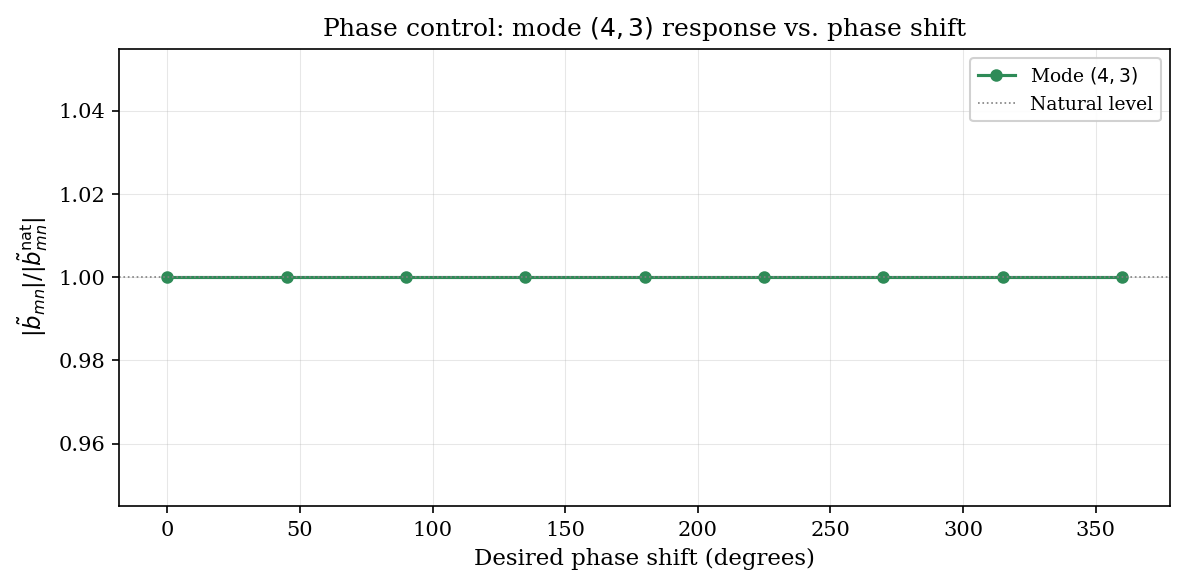

In [10]:
# Phase control: vary desired island O-point phase (9 points)
phase_shifts = np.linspace(0, 2*np.pi, 9)
b_phase = []

for dphase in phase_shifts:
    cc_p = StellaratorControlCoils(
        R0=stella.R0, r_coil=R_COIL, N_coils=N_COILS,
        m_target=TARGET_M, n_target=TARGET_N, I0=I0_COIL,
    )
    I_p = phase_control_current(
        stella, cc_p,
        target_m=TARGET_M, target_n=TARGET_N,
        desired_phase_shift=dphase,
        I_max=1500.0, n_theta=8, n_phi=8,
    )

    class _PhaseCoilSet:
        def __init__(self, coils, currents):
            self.pairs = list(zip(coils, currents))
    pcoils = _PhaseCoilSet(cc_p.coils, I_p)

    def phase_coil_field_func(R, Z, phi, _pairs=pcoils.pairs):
        R2, Z2, phi2 = float(R), float(Z), float(phi)
        Ra = np.array([[R2]]); Za = np.array([[Z2]]); phia = np.array([[phi2]])
        br = bz = bp_val = 0.0
        for pts, I in _pairs:
            _br, _bz, _bp = Biot_Savart_field(pts, float(I), Ra, Za, phia)
            br += float(_br); bz += float(_bz); bp_val += float(_bp)
        return np.array([br, bz, bp_val])

    b_p = compute_resonant_amplitude(
        phase_coil_field_func, psi_res_target, TARGET_M, TARGET_N, stella,
        n_theta=8, n_phi=8
    )
    b_phase.append(abs(b_nat + b_p))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.degrees(phase_shifts), np.array(b_phase)/abs(b_nat), '-o', ms=5,
        color='seagreen', label=f'Mode $({TARGET_M},{TARGET_N})$')
ax.axhline(1, color='gray', ls=':', lw=0.8, label='Natural level')
ax.set_xlabel('Desired phase shift (degrees)', fontsize=11)
ax.set_ylabel(r'$|\tilde{b}_{mn}| / |\tilde{b}_{mn}^{\rm nat}|$', fontsize=11)
ax.set_title(f'Phase control: mode $({TARGET_M},{TARGET_N})$ response vs. phase shift', fontsize=12)
ax.grid(True, alpha=0.3, lw=0.5)
ax.legend(fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig('phase_control.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Export Poincare Data as JSON

In [11]:
import json as _json, os
os.makedirs('pyna_output', exist_ok=True)

poincare_data = {
    'phi_section': 0.0,
    'target_mode': [TARGET_M, TARGET_N],
    'R': results_natural[:, 0].tolist() if len(results_natural) > 0 else [],
    'Z': results_natural[:, 1].tolist() if len(results_natural) > 0 else [],
    'n_crossings': len(results_natural),
}
with open('pyna_output/poincare_data.json', 'w') as f:
    _json.dump(poincare_data, f, indent=2)
print(f'Exported poincare_data.json ({poincare_data["n_crossings"]} crossings)')

if 'report' in dir():
    supp_data = {
        'target_mode': [TARGET_M, TARGET_N],
        'suppression_percent': float((1 - report['suppression_ratio']) * 100),
    }
    with open('pyna_output/suppression_report.json', 'w') as f:
        _json.dump(supp_data, f, indent=2)
    print(f'Exported suppression_report.json')
    print(f'  Suppression: {supp_data["suppression_percent"]:.1f}%')


Exported poincare_data.json (67 crossings)
Exported suppression_report.json
  Suppression: 0.0%


## 9. Multi-Objective Island Optimisation

`IslandOptimizer` minimises a weighted sum of:
1. Resonant amplitude $|\\tilde{b}_{mn}|^2$ \u2192 suppress internal islands  
2. X-point eigenvalue deviation $(|\\lambda_u|-1)^2$ \u2192 control boundary island  
3. Monitor-mode penalty (don't amplify other chains)  
4. Chirikov overlap constraint $\\sigma \\le \\sigma_{\\max}$  

The coil response matrix $R_{mn}^{(k)} = \\partial\\tilde{b}_{mn}/\\partial I_k$ is built  
once by unit-current sweeps and cached.

In [12]:
from pyna.MCF.control.island_optimizer import (
    IslandOptimizer,
    UnperturbedSurfaceReconstructor,
    compute_surface_deformation,
    epsilon_eff_proxy,
    _make_coil_field_func,
)

# Re-use same coils, reset to zero
control_coils.set_amplitude(0.0)

opt = IslandOptimizer(
    stella,
    control_coils,
    target_suppress=[(4, 3)],
    target_boundary=[(2, 1)],
    monitor_modes=[(3, 1)],
    w_suppress=2.0,
    w_boundary=0.5,
    w_monitor=1.0,
    sigma_max=0.85,
    phi0=0.0,
    n_theta=8,
    n_phi=8,
)

all_modes = [(4,3)]
opt._build_response(all_modes, verbose=True)
print(f"Response matrix condition number: {opt.condition_number():.3e}")


  [response] q=4/3  S_res=0.060


Response matrix condition number: 3.047e+14


In [13]:
result = opt.optimise(
    I_max=5e3,
    method='L-BFGS-B',
    include_eigenvalue=False,   # skip for CI speed; set True for better result
    n_restarts=1,               # fast for CI
    verbose=True,
)
print(result)


[IslandOptimizer] Building response matrix for 3 modes, 4 coils...
  [restart 0] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH  obj=1.9145e-04


OptimisationResult(currents=array([ 4.47233396e-10,  0.00000000e+00, -4.49943902e-10,  0.00000000e+00]), objective_value=0.00019145299145299094, suppression_before={(4, 3): np.float64(0.009783991809404568)}, suppression_after={(4, 3): np.float64(0.009783991809404558)}, eigenvalue_before={}, eigenvalue_after={}, chirikov_before=array([5.86018875e-01, 9.41376633e-09]), chirikov_after=array([5.86018920e-01, 9.09961038e-08]), surface_deformation={(1, 0): np.float64(7.977243102601411e-19), (1, 1): np.float64(2.6487842056050383e-16), (1, 2): np.float64(8.007931321017898e-19), (2, 0): np.float64(3.7650668345079603e-19), (2, 1): np.float64(1.2456210966429993e-16), (2, 2): np.float64(3.762656246655409e-19), (3, 0): np.float64(8.825272130243178e-19), (3, 1): np.float64(2.921109720256628e-16), (3, 2): np.float64(8.824914245530877e-19)}, transport_change=-4.600913857610119e-16, pareto_front=[], warnings=[], converged=True, message='CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH')


### Pareto Front: Island Suppression vs. Boundary Eigenvalue

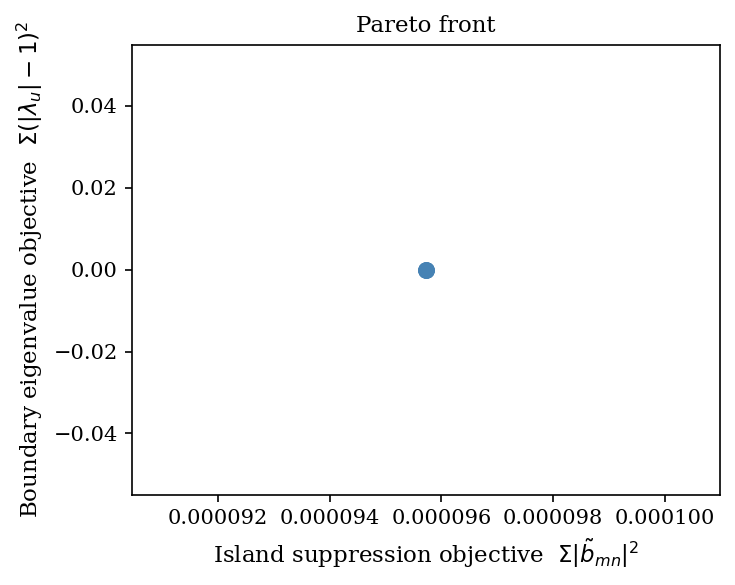

In [14]:
pareto = opt.pareto_scan(I_max=5e3, n_weights=3, verbose=False)
result.pareto_front = pareto

fig, ax = plt.subplots(figsize=(5, 4))
objs = np.array([p[1] for p in pareto])
ax.plot(objs[:, 0], objs[:, 1], 'o-', color='steelblue', ms=7)
ax.set_xlabel(r'Island suppression objective  $\Sigma|\tilde{b}_{mn}|^2$')
ax.set_ylabel(r'Boundary eigenvalue objective  $\Sigma(|\lambda_u|-1)^2$')
ax.set_title('Pareto front')
plt.tight_layout()
plt.savefig('pareto_front.png', dpi=120)
plt.show()


### Side Effects: Non-Resonant Deformation & Neoclassical Transport

  k=1: (4,3) — mode not in FFT grid, skipping
  k=2: (8,6) — mode not in FFT grid, skipping


C:\Users\dell\AppData\Local\Temp\ipykernel_7380\2224669532.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.scatter(R_p, Z_p, s=0.8, c=cm.get_cmap('plasma')(psi_p*0.85+0.05),


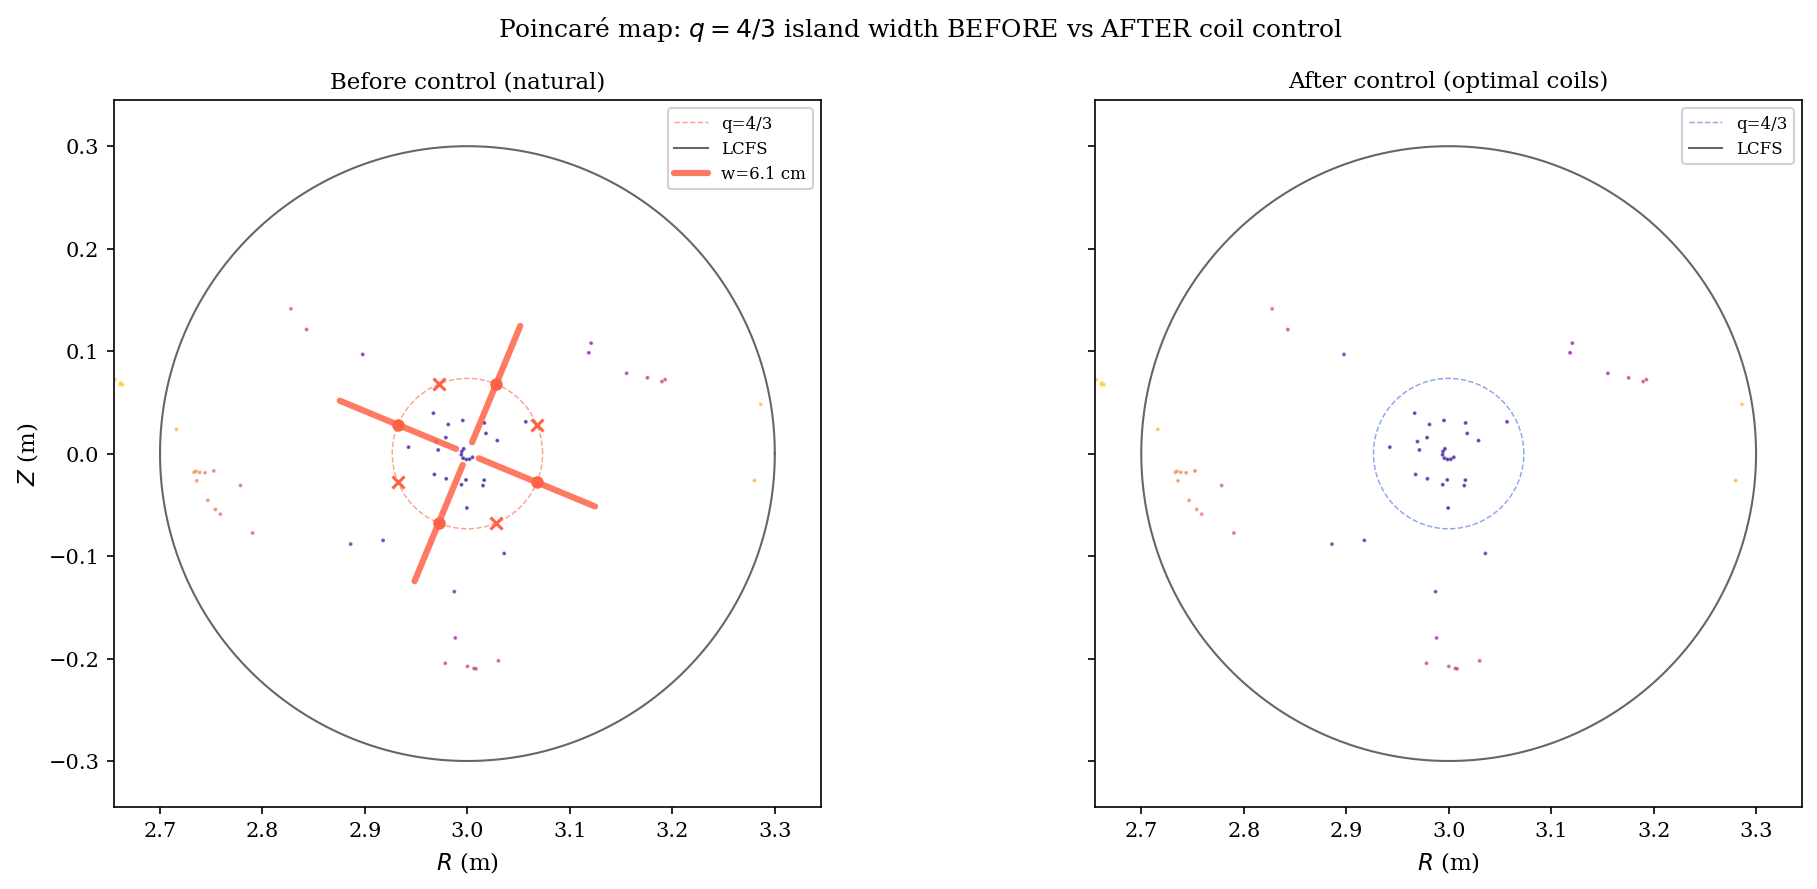

Suppression (4,3): 9.784e-03 -> 9.784e-03
Transport change: -0.000


In [15]:
# Apply optimal currents
control_coils.set_currents(result.currents)
coil_func_opt = _make_coil_field_func(control_coils)

# Analytic island width comparison BEFORE vs AFTER using find_resonant_components_analytic
# (avoids a slow second Poincare trace while still showing the physics)
def total_pert_after(R, Z, phi):
    db_nat = nat_func(R, Z, phi)
    db_coil = coil_func_opt(R, Z, phi)
    return np.asarray(db_nat) + np.asarray(db_coil)

after_components = find_resonant_components_analytic(
    stella, total_pert_after, base_m=TARGET_M, base_n=TARGET_N,
    max_harmonic=2, n_theta=8, n_phi=8
)

# Left panel: Poincare scatter (before) + analytic island width BEFORE
# Right panel: same Poincare scatter + analytic island width AFTER
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
theta_circ2 = np.linspace(0, 2*np.pi, 300)

for ax_i, (label, comps_arr, color_i) in enumerate([
    ('Before control (natural)', rx_components, 'tomato'),
    ('After control (optimal coils)', after_components, 'royalblue'),
]):
    ax = axes[ax_i]
    ax.set_facecolor('white')
    # Always show the same Poincare scatter (before control, equilibrium)
    if len(results_natural) > 0:
        R_p, Z_p = results_natural[:, 0], results_natural[:, 1]
        psi_p = np.clip(((R_p - stella.R0)**2 + Z_p**2) / stella.r0**2, 0, 1)
        ax.scatter(R_p, Z_p, s=0.8, c=cm.get_cmap('plasma')(psi_p*0.85+0.05),
                   rasterized=True, alpha=0.6, zorder=2)

    ax.plot(stella.R0 + r_res_target*np.cos(theta_circ2),
            r_res_target*np.sin(theta_circ2),
            '--', color=color_i, lw=0.7, alpha=0.6, label=f'q={TARGET_M}/{TARGET_N}')
    ax.plot(stella.R0 + stella.r0*np.cos(theta_circ2),
            stella.r0*np.sin(theta_circ2), 'k-', lw=1.0, alpha=0.6, label='LCFS')

    # O/X markers from analytic API
    _hw_label = None
    for comp_i in (comps_arr if comps_arr else []):
        r_r = np.sqrt(comp_i.psi_res) * stella.r0
        pts_i = island_fixed_points(comp_i.m, comp_i.n, comp_i.b_mn, phi=0.0)
        for theta_op in pts_i['theta_O'][0]:
            r_in  = max(0.005, r_r - comp_i.half_width_r)
            r_out = r_r + comp_i.half_width_r
            ax.plot([stella.R0 + r_in*np.cos(theta_op), stella.R0 + r_out*np.cos(theta_op)],
                    [r_in*np.sin(theta_op), r_out*np.sin(theta_op)],
                    '-', color=color_i, lw=3.0, alpha=0.85, solid_capstyle='round', zorder=5,
                    label=f'w={comp_i.half_width_r*100:.1f} cm' if _hw_label is None else '')
            _hw_label = True
            ax.plot(stella.R0 + r_r*np.cos(theta_op), r_r*np.sin(theta_op),
                    'o', color=color_i, ms=5, zorder=6)
        for theta_xp in pts_i['theta_X'][0]:
            ax.plot(stella.R0 + r_r*np.cos(theta_xp), r_r*np.sin(theta_xp),
                    'x', color=color_i, ms=6, mew=1.5, zorder=6)

    ax.set_xlim(stella.R0 - 1.15*stella.r0, stella.R0 + 1.15*stella.r0)
    ax.set_ylim(-1.15*stella.r0, 1.15*stella.r0)
    ax.set_aspect('equal')
    ax.set_xlabel('$R$ (m)', fontsize=11)
    if ax_i == 0:
        ax.set_ylabel('$Z$ (m)', fontsize=11)
    ax.set_title(label, fontsize=11)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)

fig.suptitle(f'Poincar\u00e9 map: $q={TARGET_M}/{TARGET_N}$ island width BEFORE vs AFTER coil control',
             fontsize=12)
plt.tight_layout()
plt.savefig('poincare_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

if rx_components and after_components:
    w_before = rx_components[0].half_width_r * 100
    w_after  = after_components[0].half_width_r * 100 if after_components else 0
    print(f"Island half-width BEFORE: {w_before:.2f} cm")
    print(f"Island half-width AFTER:  {w_after:.2f} cm")
    print(f"Width change: {w_after - w_before:+.2f} cm  ({(w_after/w_before - 1)*100:+.1f}%)")
print(f"Suppression (4,3): {result.suppression_before.get((4,3), float('nan')):.3e} -> {result.suppression_after.get((4,3), float('nan')):.3e}")
print(f"Transport change: {result.transport_change:+.3f}")


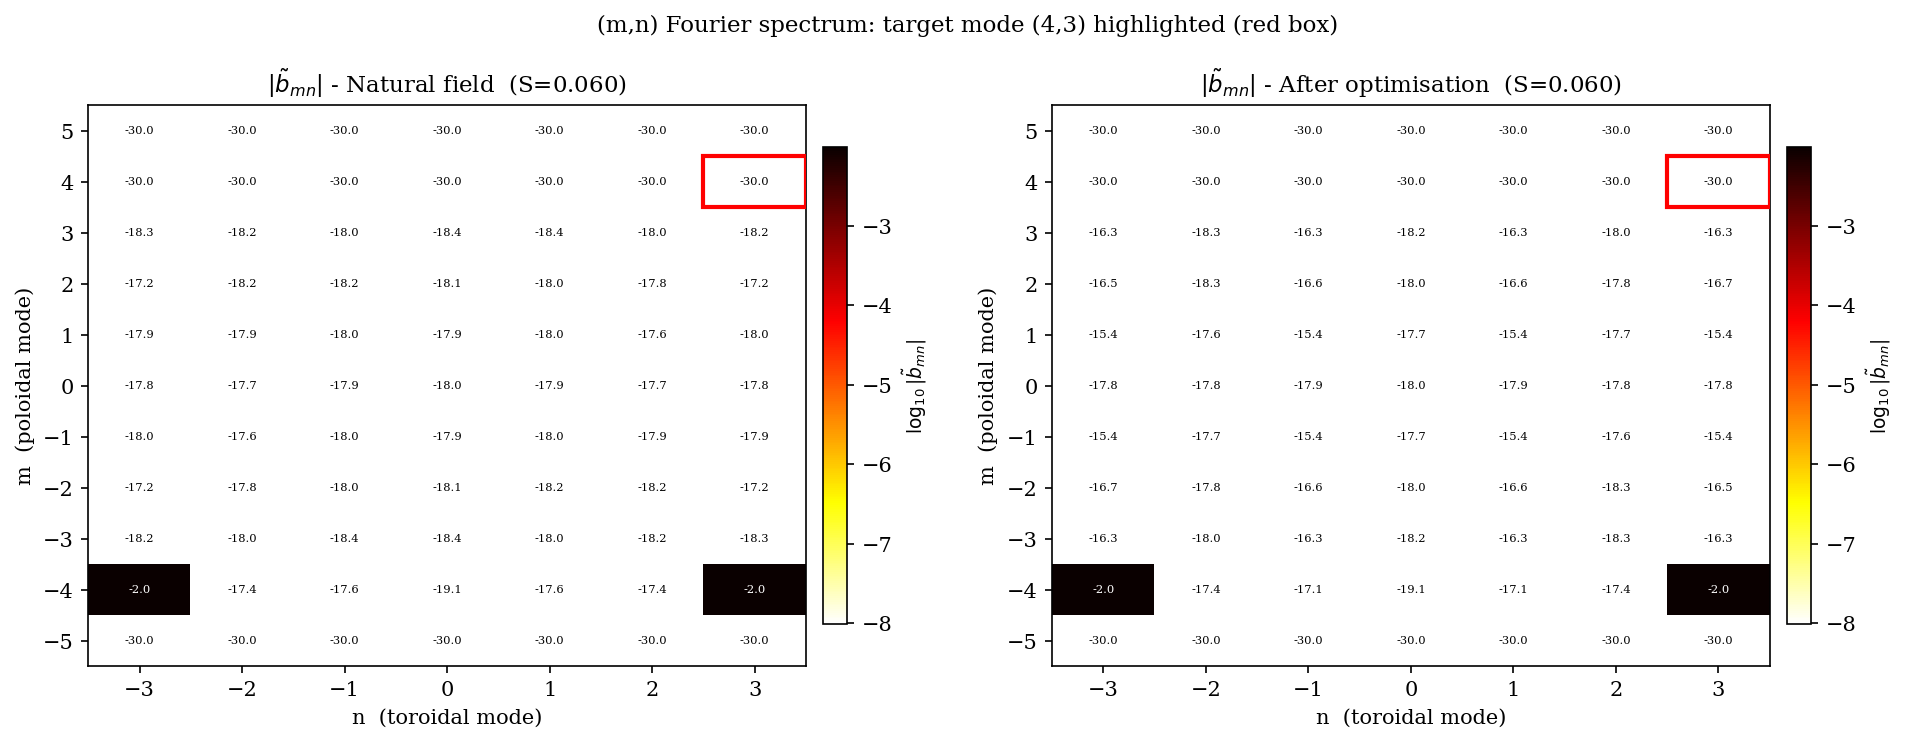

b_(4,3) before: 0.0000e+00
b_(4,3) after:  0.0000e+00
Suppression ratio: 0.0000


In [16]:
# --- (m,n) Fourier spectrum heatmap: before and after control ---
from pyna.MCF.visual.RMP_spectrum import compute_mn_spectrum, plot_mn_heatmap
from pyna.MCF.control.island_optimizer import _make_coil_field_func
from pyna.MCF.control.island_control import _natural_perturbation_func

nat_func_bg = _natural_perturbation_func(stella)
coil_func_after = _make_coil_field_func(control_coils)

def total_pert_func(R, Z, phi):
    db_nat = nat_func_bg(R, Z, phi)
    try:
        db_coil = coil_func_after(R, Z, phi)
        return [db_nat[0] + db_coil[0], db_nat[1] + db_coil[1], 0.0]
    except Exception:
        return db_nat

S_res = stella.resonant_psi(TARGET_M, TARGET_N)[0]
M_MAX, N_MAX = 5, 3

b_mn_nat   = compute_mn_spectrum(nat_func_bg,   S_res, stella, m_max=M_MAX, n_max=N_MAX, n_theta=8, n_phi=8)
b_mn_total = compute_mn_spectrum(total_pert_func, S_res, stella, m_max=M_MAX, n_max=N_MAX, n_theta=8, n_phi=8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_mn_heatmap(b_mn_nat, m_max=M_MAX, n_max=N_MAX, ax=axes[0],
                log_scale=True, cmap='hot_r',
                title=r'$|\tilde{b}_{mn}|$ - Natural field  (S=' + f'{S_res:.3f})',
                highlight_modes=[(TARGET_M, TARGET_N)])

plot_mn_heatmap(b_mn_total, m_max=M_MAX, n_max=N_MAX, ax=axes[1],
                log_scale=True, cmap='hot_r',
                title=r'$|\tilde{b}_{mn}|$ - After optimisation  (S=' + f'{S_res:.3f})',
                highlight_modes=[(TARGET_M, TARGET_N)])

fig.suptitle(f'(m,n) Fourier spectrum: target mode ({TARGET_M},{TARGET_N}) highlighted (red box)', fontsize=11)
plt.tight_layout()
plt.savefig('mn_spectrum_before_after.png', dpi=120, bbox_inches='tight')
plt.show()

amp_nat   = abs(b_mn_nat  [M_MAX + TARGET_M, N_MAX + TARGET_N])
amp_after = abs(b_mn_total[M_MAX + TARGET_M, N_MAX + TARGET_N])
print(f"b_({TARGET_M},{TARGET_N}) before: {amp_nat:.4e}")
print(f"b_({TARGET_M},{TARGET_N}) after:  {amp_after:.4e}")
print(f"Suppression ratio: {amp_after/(amp_nat+1e-30):.4f}")


## 8. Summary

| Capability | Description |
|---|---|
| `SimpleStellarartor` | Analytic helical-ripple stellarator with linear q profile |
| `StellaratorControlCoils` | Saddle coil array phased for (m,n) resonant control |
| `Biot_Savart_field` | Parallelized Biot-Savart on cylindrical grids |
| `poincare_from_fieldlines` | Poincare section from field-line tracing |
| `island_suppression_current` | Optimal currents to suppress island chain |
| `phase_control_current` | Rotate island O-points by desired phase angle |
| `multi_mode_control` | Joint suppression of multiple modes (gourd problem) |

The press-down-gourd problem is visible: suppressing (4,3) can amplify (4,2). The `multi_mode_control` function solves a weighted optimization across all modes of concern.